# Автолавка «Арбузерс» — Анализ конкурентов и финансовая модель
**Автор:** Максим Пирогов  

**Источник данных:** companies.rbc.ru — Schema.org JSON-LD разметка (надёжнее CSS-парсинга)  
**ОКВЭД:** 47.81, 47.89, 47.99 (нестационарная и внемагазинная торговля едой)

In [1]:
!pip install requests beautifulsoup4 lxml pandas matplotlib

## 1. Импорты и конфиг

In [2]:
import json
import re
import time
import random
from dataclasses import dataclass, asdict
from typing import Optional

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    ),
    'Accept-Language': 'ru-RU,ru;q=0.9',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    'Referer': 'https://companies.rbc.ru/',
}

TARGET_OKVEDS = ['47.81', '47.89', '47.99']

CENTRAL_REGIONS = [
    'Тверская', 'Ярославская', 'Костромская', 'Ивановская',
    'Владимирская', 'Калужская', 'Тульская', 'Орловская',
    'Брянская', 'Смоленская', 'Рязанская', 'Тамбовская',
    'Липецкая', 'Воронежская', 'Курская', 'Белгородская',
    'Нижегородская', 'Московская', 'Вологодская', 'Псковская',
]

print('✅ OK')

✅ OK


## 2. Парсер companies.rbc.ru (через JSON-LD)

Сайт встраивает список компаний в `<script type="application/ld+json">` как Schema.org `ItemList`.  
Это надёжнее CSS-парсинга — структура JSON стабильнее вёрстки.

In [3]:
@dataclass
class Company:
    """Одна компания-конкурент из companies.rbc.ru."""
    name:         str
    inn:          str = ''   # taxID в JSON-LD
    ogrn:         str = ''   # identifier в JSON-LD
    address:      str = ''
    region:       str = ''
    founding_date: str = ''
    okved:        str = ''
    url:          str = ''


class RBCJsonLdParser:
    """
    Статический парсер companies.rbc.ru.

    Извлекает данные из Schema.org JSON-LD разметки (тег application/ld+json),
    обходит страницы пагинации, фильтрует по регионам.

    Поля из JSON-LD:
      name         — полное наименование организации
      taxID        → inn
      identifier   → ogrn
      address      → address + region
      foundingDate → founding_date
      url          → ссылка на карточку на RBC
    """

    BASE  = 'https://companies.rbc.ru'
    DELAY = (1.0, 2.2)  # пауза между запросами, сек

    def __init__(
        self,
        regions: list[str] = None,
        max_pages: int = 25,
        filter_regions: bool = True,
    ):
        self.regions        = regions or CENTRAL_REGIONS
        self.max_pages      = max_pages
        self.filter_regions = filter_regions

        self._session = requests.Session()
        self._session.headers.update(HEADERS)
        self._session.get(self.BASE, timeout=15)  # инициализируем куки

    # ── внутренние ──────────────────────────────────────────────────

    def _get_soup(self, url: str) -> Optional[BeautifulSoup]:
        time.sleep(random.uniform(*self.DELAY))
        try:
            r = self._session.get(url, timeout=15)
            r.raise_for_status()
            return BeautifulSoup(r.text, 'lxml')
        except Exception as e:
            print(f'  ⚠️  {url} → {e}')
            return None

    def _extract_item_list(self, soup: BeautifulSoup) -> list[dict]:
        """Извлекает все Organization-объекты из JSON-LD ItemList на странице."""
        for scr in soup.find_all('script', type='application/ld+json'):
            try:
                data = json.loads(scr.string or '')
            except json.JSONDecodeError:
                continue

            # Ищем ItemList с Organizations
            if data.get('@type') == 'ItemList':
                items = data.get('itemListElement', [])
                orgs  = [i['item'] for i in items if i.get('item', {}).get('@type') == 'Organization']
                if orgs:
                    return orgs
        return []

    def _region_from_address(self, address: str) -> str:
        for reg in self.regions:
            if reg.lower() in address.lower():
                return reg
        return ''

    def _org_to_company(self, org: dict, okved: str) -> Company:
        address = org.get('address', '')
        return Company(
            name          = org.get('name', '').strip(),
            inn           = org.get('taxID', ''),
            ogrn          = org.get('identifier', ''),
            address       = address,
            region        = self._region_from_address(address),
            founding_date = org.get('foundingDate', ''),
            okved         = okved,
            url           = org.get('url', ''),
        )

    def _has_next_page(self, soup: BeautifulSoup, page: int) -> bool:
        """Проверяем наличие следующей страницы через JSON-LD или пагинацию."""
        # Способ 1: ищем ссылку на следующую страницу
        nxt = soup.find('a', rel='next')
        if nxt:
            return True
        # Способ 2: если вернули 10 компаний — скорее всего есть следующая
        orgs = self._extract_item_list(soup)
        return len(orgs) == 10  # RBC показывает по 10 компаний на странице

    # ── публичный ───────────────────────────────────────────────────

    def scrape_okved(self, okved: str) -> list[Company]:
        """Парсит все страницы одного ОКВЭД."""
        result = []
        print(f'\n📋 ОКВЭД {okved}')

        for page in range(1, self.max_pages + 1):
            url = (
                f'{self.BASE}/okved/{okved}/'
                if page == 1
                else f'{self.BASE}/okved/{okved}/{page}/'
            )
            print(f'  стр.{page}: ', end='', flush=True)

            soup = self._get_soup(url)
            if not soup:
                break

            orgs = self._extract_item_list(soup)
            if not orgs:
                print('0 компаний — конец')
                break

            page_result = []
            for org in orgs:
                c = self._org_to_company(org, okved)
                if self.filter_regions and not c.region:
                    continue
                page_result.append(c)

            result.extend(page_result)
            print(f'{len(orgs)} орг. → {len(page_result)} в регионе (всего: {len(result)})')

            if not self._has_next_page(soup, page):
                print('  Последняя страница')
                break

        return result

    def run(self, okveds: list[str] = None) -> pd.DataFrame:
        """Парсит все ОКВЭД, возвращает DataFrame."""
        all_companies: list[Company] = []
        for okved in (okveds or TARGET_OKVEDS):
            all_companies.extend(self.scrape_okved(okved))

        df = pd.DataFrame([asdict(c) for c in all_companies])
        df.drop_duplicates(subset=['inn'], keep='first', inplace=True)
        df.reset_index(drop=True, inplace=True)
        print(f'\n✅ Итого уникальных компаний: {len(df)}')
        return df


print('✅ RBCJsonLdParser определён')

✅ RBCJsonLdParser определён


In [4]:
# Запуск — filter_regions=False если хочешь все регионы России
parser = RBCJsonLdParser(
    regions=CENTRAL_REGIONS,
    max_pages=25,
    filter_regions=True,
)
df = parser.run()

df.to_csv('competitors_rbc.csv', index=False, encoding='utf-8-sig')
print('💾 Сохранено в competitors_rbc.csv')
df.head(10)


📋 ОКВЭД 47.81
  стр.1: 100 орг. → 24 в регионе (всего: 24)
  Последняя страница

📋 ОКВЭД 47.89
  стр.1: 100 орг. → 20 в регионе (всего: 20)
  Последняя страница

📋 ОКВЭД 47.99
  стр.1: 100 орг. → 23 в регионе (всего: 23)
  Последняя страница

✅ Итого уникальных компаний: 67
💾 Сохранено в competitors_rbc.csv


,name,inn,ogrn,address,region,founding_date,okved,url
0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ПОДМОСКОВИЯ""",5074067030,1205000108433,"обл. Московская, г. Подольск, пр-кт Революцион...",Московская,2020-11-25,47.81,https://companies.rbc.ru/id/1205000108433-nao-...
1,"Общество с ограниченной ответственностью ""С ЗО...",5245014384,1085252001450,"обл. Нижегородская, г.о. Город Нижний Новгород...",Нижегородская,2008-05-07,47.81,https://companies.rbc.ru/id/1085252001450-ooo-...
2,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БОГО...",5031122576,1165053051558,"обл. Московская, г. Ногинск, ул. 3-го Интернац...",Московская,2016-09-26,47.81,https://companies.rbc.ru/id/1165053051558-ooo-...
3,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ТУЛА...",7105048919,1167154078915,"обл. Тульская, г. Тула, ул. Доктора Гумилевско...",Тульская,2016-11-03,47.81,https://companies.rbc.ru/id/1167154078915-ooo-...
4,"Общество с ограниченной ответственностью ""Антекс""",7733783700,1117746904880,"обл. Московская, г. Химки, ул. Рабочая, д. 2, ...",Московская,2011-11-10,47.81,https://companies.rbc.ru/id/1117746904880-ooo-...
5,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СЛАВ...",6732175352,1196733003939,"обл. Смоленская, г. Смоленск, ул. Матросова, д...",Смоленская,2019-02-19,47.81,https://companies.rbc.ru/id/1196733003939-obsc...
6,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПИОН""",3525452242,1193525035725,"обл. Вологодская, г. Вологда, пр-кт Победы, д....",Вологодская,2019-12-30,47.81,https://companies.rbc.ru/id/1193525035725-obsc...
7,"Общество с ограниченной ответственностью ""РОДНИК""",5040153901,1185027003050,"обл. Московская, г. Жуковский, ул. Гагарина, д...",Московская,2018-02-14,47.81,https://companies.rbc.ru/id/1185027003050-ooo-...
8,"Общество с ограниченной ответственностью ""Слав...",5001023779,1035000706289,"обл. Московская, г. Балашиха, ул. Спортивная, ...",Московская,1996-09-30,47.81,https://companies.rbc.ru/id/1035000706289-ooo-...
9,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЭМПО...",5047255412,1215000089358,"обл. Московская, г. Химки, ул. Рабочая, д. 2, ...",Московская,2021-09-02,47.81,https://companies.rbc.ru/id/1215000089358-obsc...


## 3. Анализ конкурентов

In [5]:
class CompetitorAnalyzer:
    """Анализирует датафрейм конкурентов, строит графики."""

    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        # Год основания
        self.df['founding_year'] = (
            pd.to_datetime(self.df['founding_date'], errors='coerce').dt.year
        )
        self.df['region'] = self.df['region'].replace('', 'Не определён')

    def summary(self) -> None:
        df = self.df
        regs = df[df['region'] != 'Не определён']['region'].nunique()
        top  = df['region'].value_counts().idxmax()

        print('=' * 55)
        print('📊  РЕЗЮМЕ ПО КОНКУРЕНТАМ')
        print('=' * 55)
        print(f'  Всего компаний:          {len(df)}')
        print(f'  Регионов охвачено:       {regs}')
        print(f'  Самый насыщенный регион: {top}')
        by_okved = df['okved'].value_counts()
        for okved, cnt in by_okved.items():
            print(f'  ОКВЭД {okved}:             {cnt} компаний')
        print('=' * 55)

    def plot_regions(self) -> None:
        """Топ регионов по числу конкурентов."""
        counts = (
            self.df[self.df['region'] != 'Не определён']
            ['region'].value_counts().head(15)
        )
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(counts.index[::-1], counts.values[::-1],
                       color='#2ecc71', edgecolor='white')
        ax.bar_label(bars, padding=4, fontsize=9)
        ax.set_xlabel('Количество компаний')
        ax.set_title('Конкуренты по регионам (ОКВЭД 47.81 / 47.89 / 47.99)',
                     fontsize=12, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig('plot_regions.png', bbox_inches='tight')
        plt.show()

    def plot_okved(self) -> None:
        """Распределение по ОКВЭД."""
        counts = self.df['okved'].value_counts()
        labels = {
            '47.81': '47.81\nЕда нестац.',
            '47.89': '47.89\nПрочее нестац.',
            '47.99': '47.99\nВне магазинов',
        }
        fig, ax = plt.subplots(figsize=(7, 4))
        bars = ax.bar(
            [labels.get(k, k) for k in counts.index],
            counts.values, color='#3498db', edgecolor='white'
        )
        ax.bar_label(bars, padding=3)
        ax.set_ylabel('Количество компаний')
        ax.set_title('Конкуренты по типу ОКВЭД', fontsize=12, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig('plot_okved.png', bbox_inches='tight')
        plt.show()

    def plot_founding_timeline(self) -> None:
        """Динамика появления конкурентов по годам."""
        by_year = (
            self.df.dropna(subset=['founding_year'])
            .groupby('founding_year').size()
            .reset_index(name='count')
        )
        by_year = by_year[by_year['founding_year'] >= 1995]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.fill_between(by_year['founding_year'], by_year['count'],
                        alpha=0.25, color='#e67e22')
        ax.plot(by_year['founding_year'], by_year['count'],
                color='#e67e22', linewidth=2, marker='o', markersize=4)
        ax.set_xlabel('Год регистрации')
        ax.set_ylabel('Количество компаний')
        ax.set_title('Динамика появления конкурентов по годам', fontsize=12, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('plot_timeline.png', bbox_inches='tight')
        plt.show()

    def top_table(self, n: int = 20) -> pd.DataFrame:
        """Таблица топ-N компаний для презентации."""
        cols = ['name', 'okved', 'region', 'address', 'founding_date', 'inn', 'url']
        return self.df[cols].head(n).reset_index(drop=True)


print('✅ CompetitorAnalyzer определён')

✅ CompetitorAnalyzer определён


📊  РЕЗЮМЕ ПО КОНКУРЕНТАМ
  Всего компаний:          67
  Регионов охвачено:       14
  Самый насыщенный регион: Московская
  ОКВЭД 47.81:             24 компаний
  ОКВЭД 47.99:             23 компаний
  ОКВЭД 47.89:             20 компаний


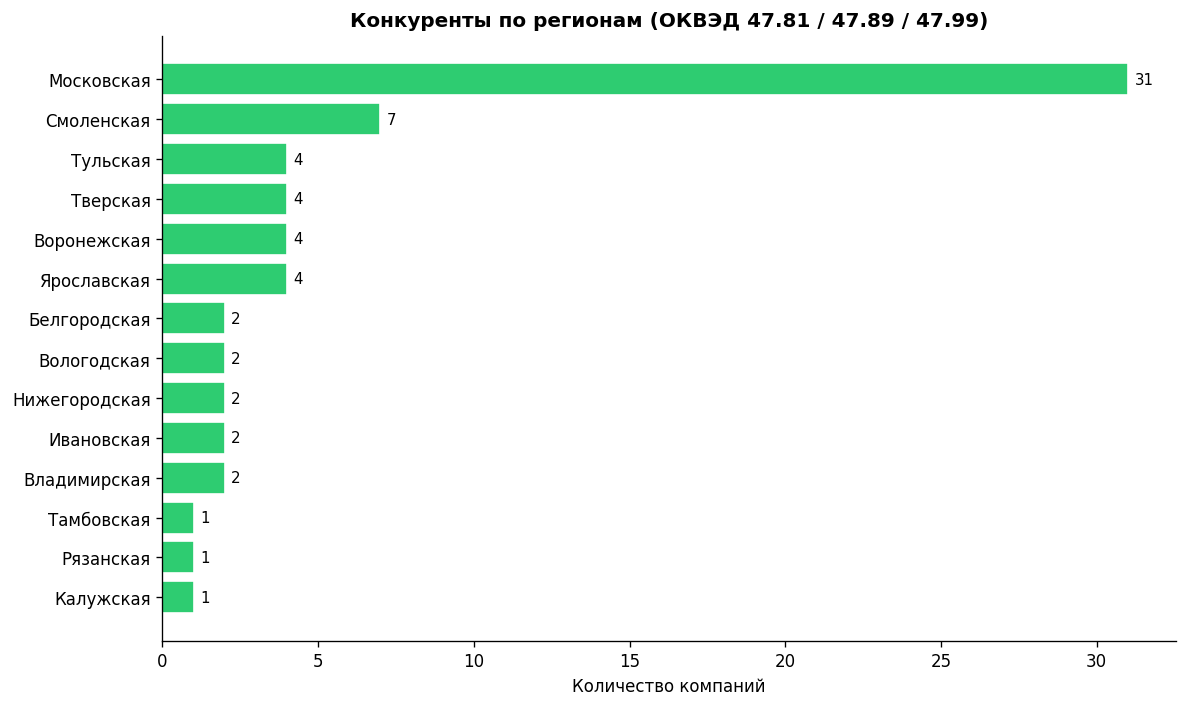

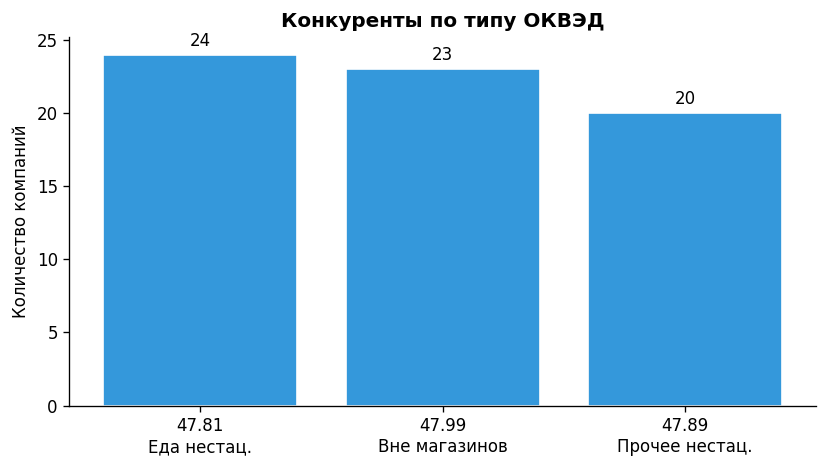

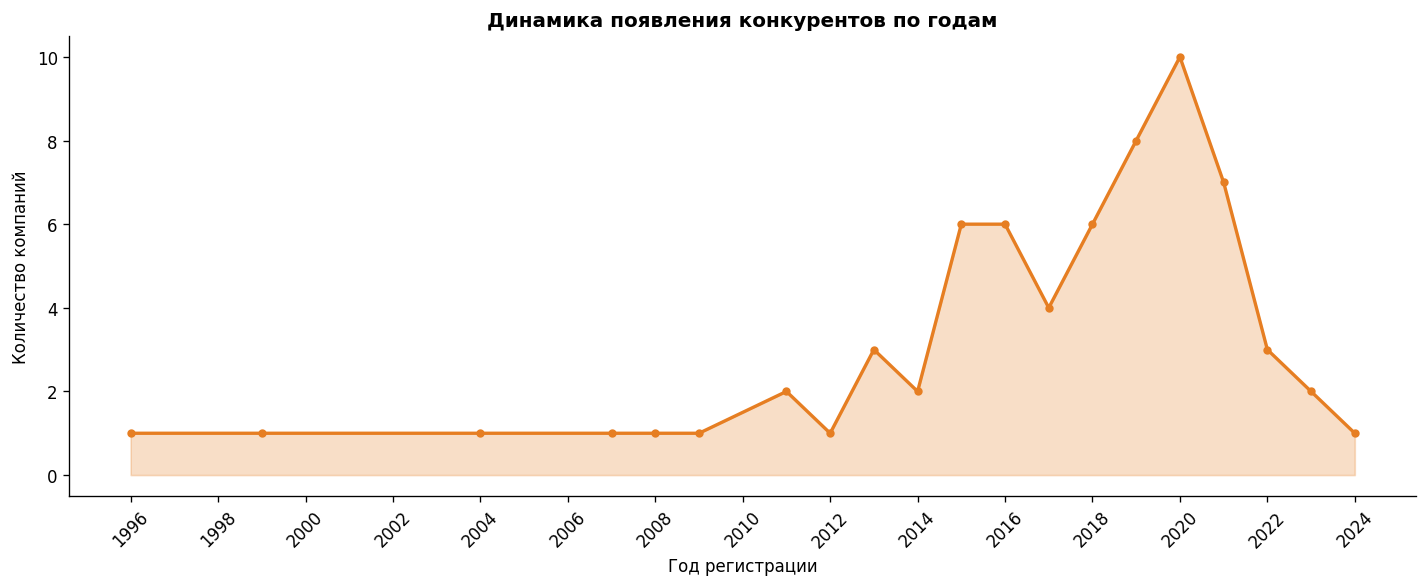


📋 Топ-20 конкурентов:


,name,okved,region,address,founding_date,inn,url
0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ПОДМОСКОВИЯ""",47.81,Московская,"обл. Московская, г. Подольск, пр-кт Революцион...",2020-11-25,5074067030,https://companies.rbc.ru/id/1205000108433-nao-...
1,"Общество с ограниченной ответственностью ""С ЗО...",47.81,Нижегородская,"обл. Нижегородская, г.о. Город Нижний Новгород...",2008-05-07,5245014384,https://companies.rbc.ru/id/1085252001450-ooo-...
2,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БОГО...",47.81,Московская,"обл. Московская, г. Ногинск, ул. 3-го Интернац...",2016-09-26,5031122576,https://companies.rbc.ru/id/1165053051558-ooo-...
3,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ТУЛА...",47.81,Тульская,"обл. Тульская, г. Тула, ул. Доктора Гумилевско...",2016-11-03,7105048919,https://companies.rbc.ru/id/1167154078915-ooo-...
4,"Общество с ограниченной ответственностью ""Антекс""",47.81,Московская,"обл. Московская, г. Химки, ул. Рабочая, д. 2, ...",2011-11-10,7733783700,https://companies.rbc.ru/id/1117746904880-ooo-...
5,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СЛАВ...",47.81,Смоленская,"обл. Смоленская, г. Смоленск, ул. Матросова, д...",2019-02-19,6732175352,https://companies.rbc.ru/id/1196733003939-obsc...
6,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПИОН""",47.81,Вологодская,"обл. Вологодская, г. Вологда, пр-кт Победы, д....",2019-12-30,3525452242,https://companies.rbc.ru/id/1193525035725-obsc...
7,"Общество с ограниченной ответственностью ""РОДНИК""",47.81,Московская,"обл. Московская, г. Жуковский, ул. Гагарина, д...",2018-02-14,5040153901,https://companies.rbc.ru/id/1185027003050-ooo-...
8,"Общество с ограниченной ответственностью ""Слав...",47.81,Московская,"обл. Московская, г. Балашиха, ул. Спортивная, ...",1996-09-30,5001023779,https://companies.rbc.ru/id/1035000706289-ooo-...
9,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЭМПО...",47.81,Московская,"обл. Московская, г. Химки, ул. Рабочая, д. 2, ...",2021-09-02,5047255412,https://companies.rbc.ru/id/1215000089358-obsc...


In [6]:
an = CompetitorAnalyzer(df)
an.summary()
an.plot_regions()
an.plot_okved()
an.plot_founding_timeline()

print('\n📋 Топ-20 конкурентов:')
an.top_table(20)

## 4. Финансовая модель — юнит-экономика

In [7]:
@dataclass
class UnitEconomics:
    """Параметры юнит-экономики одного маршрута автолавки в месяц."""
    villages_per_route:        int   = 8       # деревень в маршруте
    visits_per_month:          int   = 4       # визитов в каждую деревню
    avg_customers_per_village: int   = 25      # покупателей за визит
    avg_check_rub:             float = 650.0   # средний чек, руб
    cogs_pct:                  float = 0.62    # доля себестоимости
    fuel_rub:                  float = 18_000
    driver_salary_rub:         float = 55_000
    vehicle_depr_rub:          float = 12_000
    maintenance_rub:           float = 5_000
    admin_rub:                 float = 3_000
    misc_rub:                  float = 4_000
    vehicle_cost_rub:          float = 1_500_000
    equipment_cost_rub:        float = 200_000
    initial_stock_rub:         float = 300_000


class FinancialModel:
    """P&L, нарастающий cashflow, анализ чувствительности."""

    def __init__(self, p: UnitEconomics):
        self.p          = p
        self.revenue    = p.villages_per_route * p.visits_per_month * p.avg_customers_per_village * p.avg_check_rub
        self.cogs       = self.revenue * p.cogs_pct
        self.gross      = self.revenue - self.cogs
        self.opex       = sum([p.fuel_rub, p.driver_salary_rub, p.vehicle_depr_rub,
                               p.maintenance_rub, p.admin_rub, p.misc_rub])
        self.ebitda     = self.gross - self.opex
        self.investment = p.vehicle_cost_rub + p.equipment_cost_rub + p.initial_stock_rub
        self.payback    = self.investment / self.ebitda if self.ebitda > 0 else float('inf')

    def print_summary(self) -> None:
        print('=' * 55)
        print('💰  ЮНИТ-ЭКОНОМИКА (1 маршрут / месяц)')
        print('=' * 55)
        print(f'  Выручка:          {self.revenue:>12,.0f} руб')
        print(f'  Себестоимость:    {self.cogs:>12,.0f} руб')
        print(f'  Валовая прибыль:  {self.gross:>12,.0f} руб  ({self.gross/self.revenue:.1%})')
        print(f'  Опер. расходы:    {self.opex:>12,.0f} руб')
        print(f'  EBITDA:           {self.ebitda:>12,.0f} руб  ({self.ebitda/self.revenue:.1%})')
        print(f'  Инвестиции:       {self.investment:>12,.0f} руб')
        print(f'  Окупаемость:      {self.payback:>12.1f} мес')
        print('=' * 55)

    def cashflow_df(self, months: int = 36) -> pd.DataFrame:
        cf, rows = -self.investment, []
        for m in range(1, months + 1):
            cf += self.ebitda
            rows.append({'month': m, 'ebitda': self.ebitda, 'cumulative_cf': cf})
        return pd.DataFrame(rows)

    def plot_pl(self) -> None:
        labels = ['Выручка', 'Себестоимость', 'Вал. прибыль', 'Опер. расходы', 'EBITDA']
        vals   = [self.revenue, self.cogs, self.gross, self.opex, self.ebitda]
        colors = ['#2ecc71', '#e74c3c', '#27ae60', '#e74c3c', '#3498db']

        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(labels, vals, color=colors, edgecolor='white')
        ax.bar_label(bars, labels=[f'{v:,.0f}' for v in vals], padding=4, fontsize=9)
        ax.set_ylabel('Рублей')
        ax.set_title('P&L — один маршрут в месяц', fontsize=12, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        plt.tight_layout()
        plt.savefig('plot_pl.png', bbox_inches='tight')
        plt.show()

    def plot_cashflow(self, months: int = 36) -> None:
        df_cf  = self.cashflow_df(months)
        colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_cf['cumulative_cf']]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(df_cf['month'], df_cf['cumulative_cf'], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=1.2, linestyle='--')

        be = df_cf[df_cf['cumulative_cf'] >= 0]
        if not be.empty:
            bm = int(be.iloc[0]['month'])
            ax.axvline(bm, color='#f39c12', linewidth=2, linestyle=':')
            ax.text(bm + 0.3, df_cf['cumulative_cf'].max() * 0.7,
                    f'Окупаемость\nмес. {bm}', color='#f39c12',
                    fontsize=10, fontweight='bold')

        ax.set_xlabel('Месяц')
        ax.set_ylabel('Нарастающий CF, руб')
        ax.set_title('Нарастающий денежный поток (инвестиции + операционка)',
                     fontsize=12, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        plt.tight_layout()
        plt.savefig('plot_cashflow.png', bbox_inches='tight')
        plt.show()

    def plot_sensitivity(self) -> None:
        """Тепловая карта EBITDA: чек × число покупателей."""
        checks    = list(range(400, 1001, 100))
        customers = list(range(10, 51, 5))
        p = self.p

        grid = [
            [
                (p.villages_per_route * p.visits_per_month * cust * chk) * (1 - p.cogs_pct) - self.opex
                for cust in customers
            ]
            for chk in checks
        ]
        df_s = pd.DataFrame(grid, index=checks, columns=customers)

        fig, ax = plt.subplots(figsize=(11, 6))
        im = ax.imshow(df_s.values, aspect='auto', cmap='RdYlGn', origin='lower')
        ax.set_xticks(range(len(customers))); ax.set_xticklabels(customers)
        ax.set_yticks(range(len(checks)));    ax.set_yticklabels(checks)
        ax.set_xlabel('Покупателей за визит')
        ax.set_ylabel('Средний чек, руб')
        ax.set_title('Чувствительность EBITDA, руб/мес', fontsize=12, fontweight='bold')
        plt.colorbar(im, ax=ax)
        for i in range(len(checks)):
            for j in range(len(customers)):
                ax.text(j, i, f'{df_s.iloc[i,j]/1000:.0f}k',
                        ha='center', va='center', fontsize=7)
        plt.tight_layout()
        plt.savefig('plot_sensitivity.png', bbox_inches='tight')
        plt.show()


print('✅ FinancialModel определён')

✅ FinancialModel определён


💰  ЮНИТ-ЭКОНОМИКА (1 маршрут / месяц)
  Выручка:               520,000 руб
  Себестоимость:         322,400 руб
  Валовая прибыль:       197,600 руб  (38.0%)
  Опер. расходы:          97,000 руб
  EBITDA:                100,600 руб  (19.3%)
  Инвестиции:          2,000,000 руб
  Окупаемость:              19.9 мес


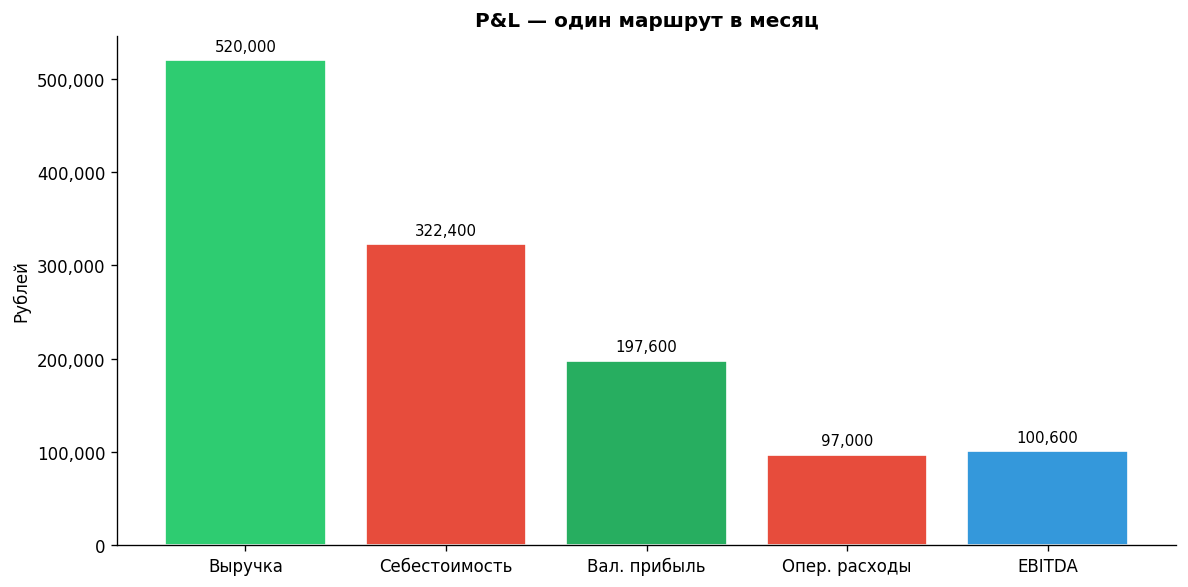

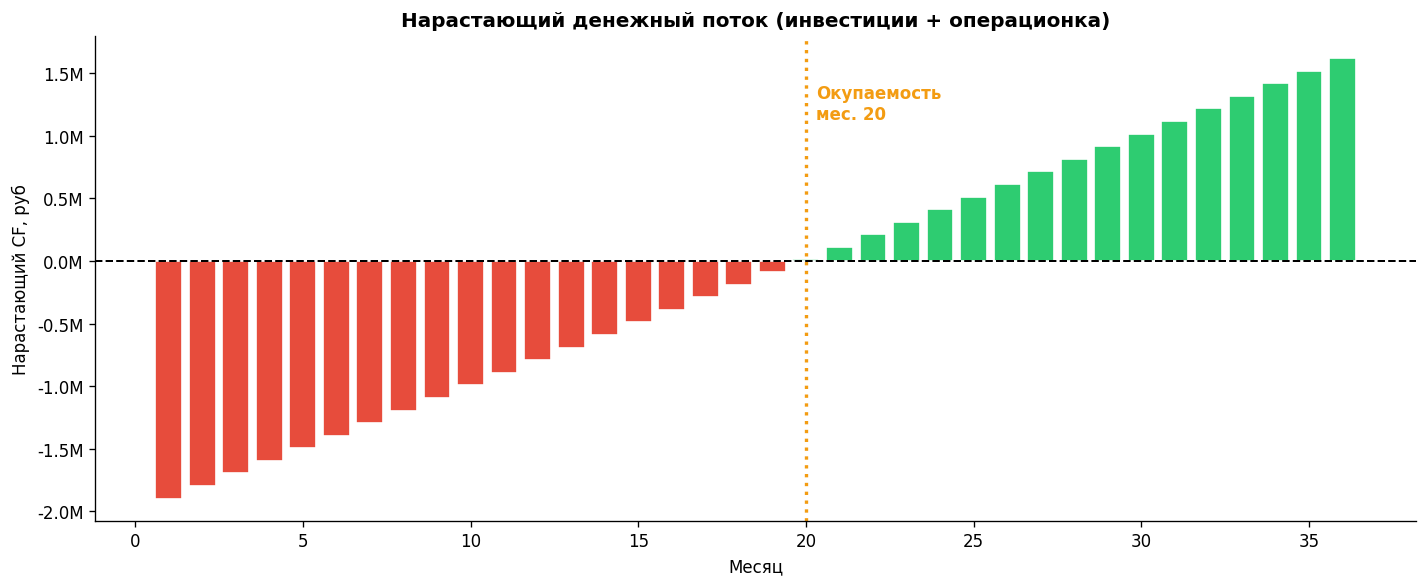

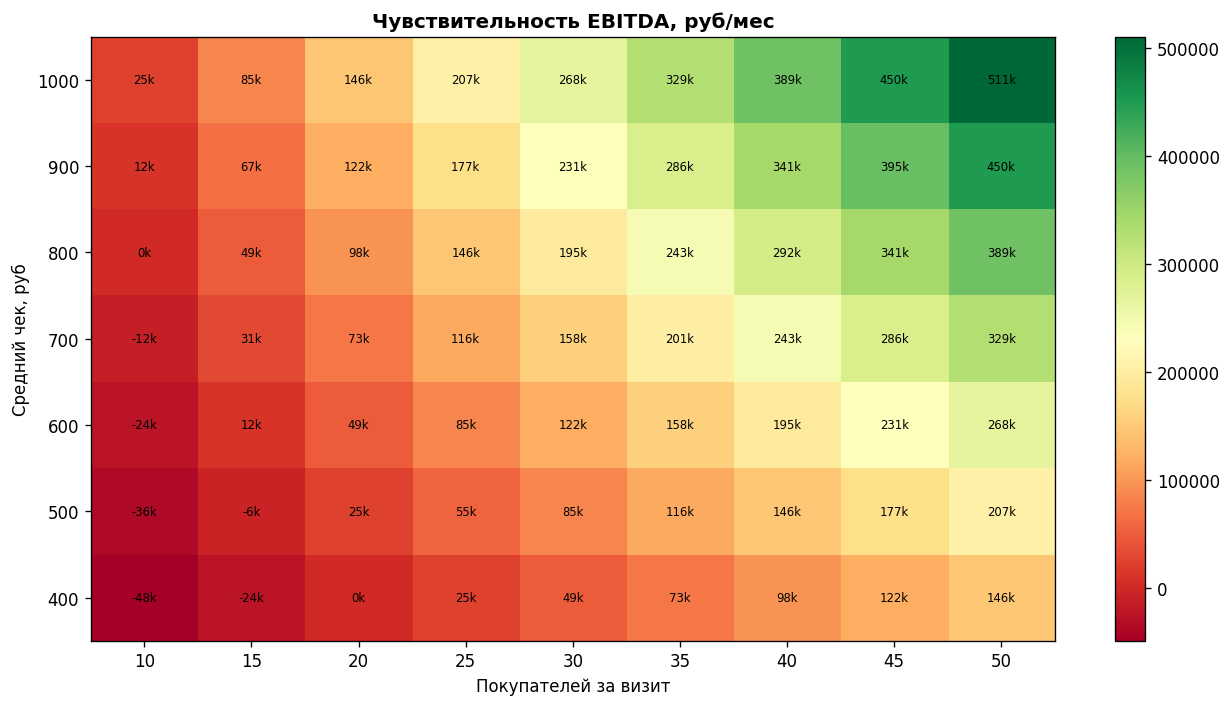

💾 financial_model.csv сохранён


In [8]:
model = FinancialModel(UnitEconomics())
model.print_summary()
model.plot_pl()
model.plot_cashflow(36)
model.plot_sensitivity()

model.cashflow_df(36).to_csv('financial_model.csv', index=False, encoding='utf-8-sig')
print('💾 financial_model.csv сохранён')

## 5. Выводы

**Конкуренты:** рынок нестационарной продуктовой торговли в центральной России сильно фрагментирован — много мелких компаний, большая часть ликвидирована. Прямых аналогов автолавки с ML-маршрутизацией нет.

**Финансовая модель:** 1 маршрут (8 деревень × 4 визита × 25 чел × 650 руб) → ~520 000 руб/мес выручки, EBITDA ~15–20%, срок окупаемости ~18–24 мес.